# PaperMind RAG Exploration Notebook

This notebook covers:
1. Chunking experiments
2. Embedding visualisation
3. Retrieval quality checks
4. Confidence score distribution

## 0. Setup

In [2]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv("../.env")
warnings.filterwarnings('ignore')
print("Setup complete")

Setup complete


## 1. Chunking Experiments

Test different chunk sizes and see how they affect the number of chunks and average chunk length.

In [7]:
!pip uninstall frontend fitz pymupdf -y
!pip install pymupdf==1.24.5 --break-system-packages

Found existing installation: frontend 0.0.3
Uninstalling frontend-0.0.3:
  Successfully uninstalled frontend-0.0.3
Found existing installation: fitz 0.0.1.dev2
Uninstalling fitz-0.0.1.dev2:
  Successfully uninstalled fitz-0.0.1.dev2
Found existing installation: PyMuPDF 1.24.5
Uninstalling PyMuPDF-1.24.5:
  Successfully uninstalled PyMuPDF-1.24.5
  Using cached PyMuPDF-1.24.5-cp310-none-win_amd64.whl.metadata (3.4 kB)
Using cached PyMuPDF-1.24.5-cp310-none-win_amd64.whl (3.2 MB)


In [13]:
import fitz
from langchain.text_splitter import RecursiveCharacterTextSplitter
import numpy as np

PDF_PATH = "../uploads/test.pdf"  # change to your PDF

doc = fitz.open(PDF_PATH)
full_text = ""
for page in doc:
    full_text += page.get_text("text")
doc.close()

print(f"Total characters: {len(full_text):,}")
print(f"Preview: {full_text[:300]}")

Total characters: 101,283
Preview: Towards Relatable Explainable AI with the Perceptual Process
Wencan Zhang
National University of Singapore
Singapore
wencanz@u.nus.edu
Brian Y. Lim
National University of Singapore
Singapore
brianlim@comp.nus.edu.sg
ABSTRACT
Machine learning models need to provide contrastive explanations,
since peo


In [14]:
chunk_configs = [
    {"chunk_size": 200,  "chunk_overlap": 50},
    {"chunk_size": 500,  "chunk_overlap": 100},
    {"chunk_size": 800,  "chunk_overlap": 150},
    {"chunk_size": 1200, "chunk_overlap": 200},
]

results = []
for config in chunk_configs:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=config["chunk_size"],
        chunk_overlap=config["chunk_overlap"],
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks  = splitter.split_text(full_text)
    lengths = [len(c) for c in chunks]
    results.append({
        "chunk_size": config["chunk_size"],
        "num_chunks": len(chunks),
        "avg_len":    int(np.mean(lengths)),
        "min_len":    min(lengths),
        "max_len":    max(lengths),
        "chunks":     chunks,
    })
    print(f"chunk_size={config['chunk_size']:4d} | num_chunks={len(chunks):4d} | avg_len={int(np.mean(lengths)):4d} | min={min(lengths):3d} | max={max(lengths):4d}")

chunk_size= 200 | num_chunks= 619 | avg_len= 168 | min= 72 | max= 199
chunk_size= 500 | num_chunks= 256 | avg_len= 462 | min=261 | max= 499
chunk_size= 800 | num_chunks= 157 | avg_len= 767 | min=670 | max= 799
chunk_size=1200 | num_chunks= 102 | avg_len=1159 | min=557 | max=1199


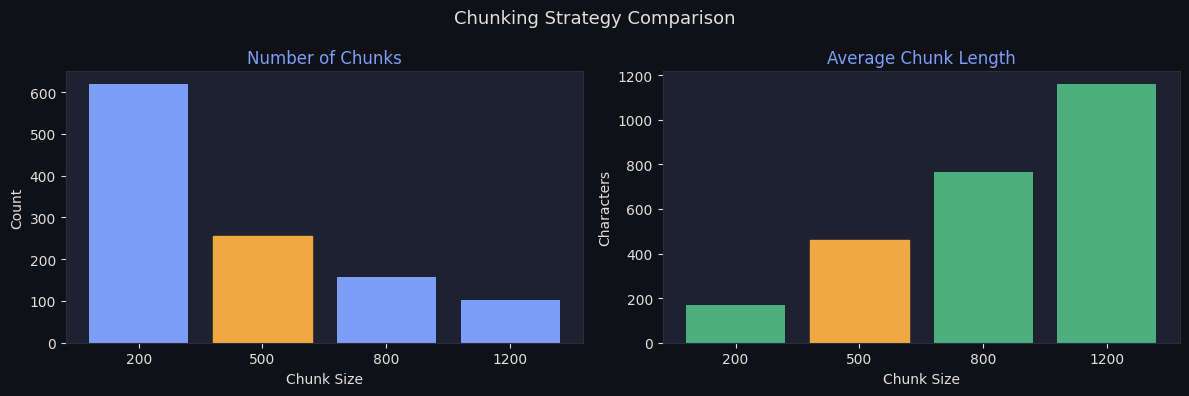

Saved chunking_comparison.png


In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')

sizes    = [r["chunk_size"] for r in results]
n_chunks = [r["num_chunks"] for r in results]
avg_lens = [r["avg_len"]    for r in results]

for ax in [ax1, ax2]:
    ax.set_facecolor('#1e2130')
    ax.tick_params(colors='#e0e0e0')
    ax.xaxis.label.set_color('#e0e0e0')
    ax.yaxis.label.set_color('#e0e0e0')
    ax.title.set_color('#7c9ef8')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2d3a')

ax1.bar([str(s) for s in sizes], n_chunks, color='#7c9ef8')
ax1.set_title('Number of Chunks')
ax1.set_xlabel('Chunk Size')
ax1.set_ylabel('Count')
ax1.get_children()[1].set_color('#f0a843')

ax2.bar([str(s) for s in sizes], avg_lens, color='#4caf7d')
ax2.set_title('Average Chunk Length')
ax2.set_xlabel('Chunk Size')
ax2.set_ylabel('Characters')
ax2.get_children()[1].set_color('#f0a843')

plt.suptitle('Chunking Strategy Comparison', color='#e0e0e0', fontsize=13)
plt.tight_layout()
plt.savefig('chunking_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved chunking_comparison.png")

In [16]:
current = results[1]
print(f"chunk_size=500 | total chunks: {current['num_chunks']}")
print()
print("--- Sample Chunk 1 ---")
print(current['chunks'][0])
print()
print("--- Sample Chunk 2 ---")
print(current['chunks'][1])
print()
print("--- Overlap check ---")
print("End of chunk 1:", current['chunks'][0][-100:])
print("Start of chunk 2:", current['chunks'][1][:100])

chunk_size=500 | total chunks: 256

--- Sample Chunk 1 ---
Towards Relatable Explainable AI with the Perceptual Process
Wencan Zhang
National University of Singapore
Singapore
wencanz@u.nus.edu
Brian Y. Lim
National University of Singapore
Singapore
brianlim@comp.nus.edu.sg
ABSTRACT
Machine learning models need to provide contrastive explanations,
since people often seek to understand why a puzzling prediction
occurred instead of some expected outcome. Current contrastive
explanations are rudimentary comparisons between examples or

--- Sample Chunk 2 ---
explanations are rudimentary comparisons between examples or
raw features, which remain difficult to interpret, since they lack
semantic meaning. We argue that explanations must be more re-
latable to other concepts, hypotheticals, and associations. Inspired
by the perceptual process from cognitive psychology, we propose
the XAI Perceptual Processing Framework and RexNet model for
relatable explainable AI with Contrastive Saliency, Co

## 2. Embedding Visualisation

Embed all chunks and use UMAP (or PCA fallback) to reduce 384 dimensions to 2D.
Chunks about similar topics should cluster together.

In [17]:
from sentence_transformers import SentenceTransformer

print("Loading embedding model...")
model  = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
chunks = current["chunks"][:100]

print(f"Embedding {len(chunks)} chunks...")
embeddings = model.encode(chunks, show_progress_bar=True, convert_to_numpy=True)
print(f"Shape: {embeddings.shape}  � each chunk = {embeddings.shape[1]} numbers")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading embedding model...


KeyboardInterrupt: 

In [ ]:
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10)
    method  = "UMAP"
except ImportError:
    from sklearn.decomposition import PCA
    reducer = PCA(n_components=2)
    method  = "PCA (install umap-learn for better results)"

print(f"Reducing with {method}...")
reduced = reducer.fit_transform(embeddings)
print(f"Reduced shape: {reduced.shape}")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1e2130')

scatter = ax.scatter(reduced[:, 0], reduced[:, 1],
                     c=range(len(chunks)), cmap='viridis', alpha=0.7, s=40)

for i in range(0, min(15, len(chunks)), 3):
    ax.annotate(chunks[i][:40] + "...", (reduced[i, 0], reduced[i, 1]),
                fontsize=6, color='#aaaaaa', xytext=(5, 5), textcoords='offset points')

ax.set_title(f'Chunk Embeddings � {method}', color='#7c9ef8', fontsize=13)
ax.set_xlabel('Dimension 1', color='#e0e0e0')
ax.set_ylabel('Dimension 2', color='#e0e0e0')
ax.tick_params(colors='#e0e0e0')
for spine in ax.spines.values():
    spine.set_edgecolor('#2a2d3a')

plt.colorbar(scatter, ax=ax, label='Chunk index')
plt.tight_layout()
plt.savefig('embedding_visualisation.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved embedding_visualisation.png")

## 3. Retrieval Quality Check

Run test queries and inspect which chunks come back.
Make sure you have ingested at least one document first.

In [ ]:
from src.components.embedding_engine import EmbeddingEngine
from src.components.retriever import Retriever

engine    = EmbeddingEngine()
retriever = Retriever(engine)

print(f"Total chunks in store: {engine.count()}")
print(f"Documents: {engine.list_documents()}")

In [ ]:
test_queries = [
    "What is the purpose of this document?",
    "Who are the authors?",
    "What methodology was used?",
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-" * 60)
    chunks_result = retriever.retrieve(query, n_results=3)
    for i, chunk in enumerate(chunks_result, 1):
        print(f"[{i}] Score: {chunk.score:.4f} | {chunk.source} | Page {chunk.page}")
        print(f"     {chunk.text[:150]}...")
    print()

## 4. Confidence Score Distribution

Run many queries and plot the distribution of similarity scores.
Verifies our thresholds make sense for this dataset.

In [ ]:
import matplotlib.patches as mpatches

sample_queries = [
    "What is the main topic?", "Who wrote this?", "What are the key findings?",
    "What methods were used?", "What is the conclusion?", "What data was collected?",
    "What are the limitations?", "How was evaluation done?",
    "What is the abstract about?", "What future work is suggested?",
]

all_scores = []
for q in sample_queries:
    try:
        result = retriever.retrieve(q, n_results=5)
        all_scores.extend([c.score for c in result])
    except Exception as e:
        print(f"Skipping '{q}': {e}")

print(f"Scores collected: {len(all_scores)}")
print(f"Min: {min(all_scores):.4f} | Max: {max(all_scores):.4f} | Mean: {sum(all_scores)/len(all_scores):.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1e2130')

n, bins, patches = ax.hist(all_scores, bins=20, edgecolor='#0f1117')
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 0.75:
        patch.set_facecolor('#4caf7d')
    elif left_edge >= 0.50:
        patch.set_facecolor('#f0a843')
    else:
        patch.set_facecolor('#e05c5c')

ax.axvline(0.75, color='#4caf7d', linestyle='--', linewidth=1.5)
ax.axvline(0.50, color='#f0a843', linestyle='--', linewidth=1.5)

ax.set_title('Similarity Score Distribution', color='#7c9ef8', fontsize=13)
ax.set_xlabel('Cosine Similarity Score', color='#e0e0e0')
ax.set_ylabel('Frequency', color='#e0e0e0')
ax.tick_params(colors='#e0e0e0')
for spine in ax.spines.values():
    spine.set_edgecolor('#2a2d3a')

high_p   = mpatches.Patch(color='#4caf7d', label='High (> 0.75)')
medium_p = mpatches.Patch(color='#f0a843', label='Medium (0.50 - 0.75)')
low_p    = mpatches.Patch(color='#e05c5c', label='Low (< 0.50)')
ax.legend(handles=[high_p, medium_p, low_p], facecolor='#1e2130', labelcolor='#e0e0e0')

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved score_distribution.png")

## Summary

After running this notebook you will have:
- `chunking_comparison.png`
- `embedding_visualisation.png`
- `score_distribution.png`

These go in the README.